# Notebook 01 — Exploratory Data Analysis
# Project: Ad Engagement Analysis
# Goal: Understand campaign interaction patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
import os
import sys
import warnings
warnings.filterwarnings('ignore')

try:
    df = pd.read_csv('../data/comments_cleaned.csv')
    print("Dataset 'comments_cleaned.csv' loaded successfully.")
    print("Shape:", df.shape)
except FileNotFoundError:
    print("Dataset not found. Please ensure 'comments_cleaned.csv' is in the 'data' folder.")
    sys.exit(1)

display(df.head())

Dataset 'comments_cleaned.csv' loaded successfully.
Shape: (7488, 9)


,Unnamed: 0,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,0,1,fantastic. wonderful experience.,2,1,13-04-2023 08:04,April 14,yes,1
1,1,2,broke easily. awful.,3,1,13-04-2023 08:04,April 14,no,2
2,2,3,met expectations. five stars.,5,1,13-04-2023 08:04,April 14,no,4
3,3,4,very satisfied. wonderful experience.,14,1,13-04-2023 08:04,April 14,yes,2
4,4,5,worst purchase. one star.,17,1,13-04-2023 08:04,April 14,yes,1


## 1. Environment Setup and Data Loading
Import essential data science libraries (Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn) and load the Instagram user behavior dataset.

## 2. Descriptive Statistics and EDA
Distributions of core user engagement metrics.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           7488 non-null   int64 
 1   id                   7488 non-null   int64 
 2   comment              7488 non-null   object
 3   User  id             7488 non-null   int64 
 4   Photo id             7488 non-null   int64 
 5   created Timestamp    7488 non-null   object
 6   posted date          7488 non-null   object
 7   emoji used           7488 non-null   object
 8   Hashtags used count  7488 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 526.6+ KB
None
Target Distribution:
target_emoji
1    3744
0    3744
Name: count, dtype: int64
Missing Values:
id                     0
comment                0
User  id               0
Photo id               0
created Timestamp      0
posted date            0
emoji used             0
Hashtags used count    0
co

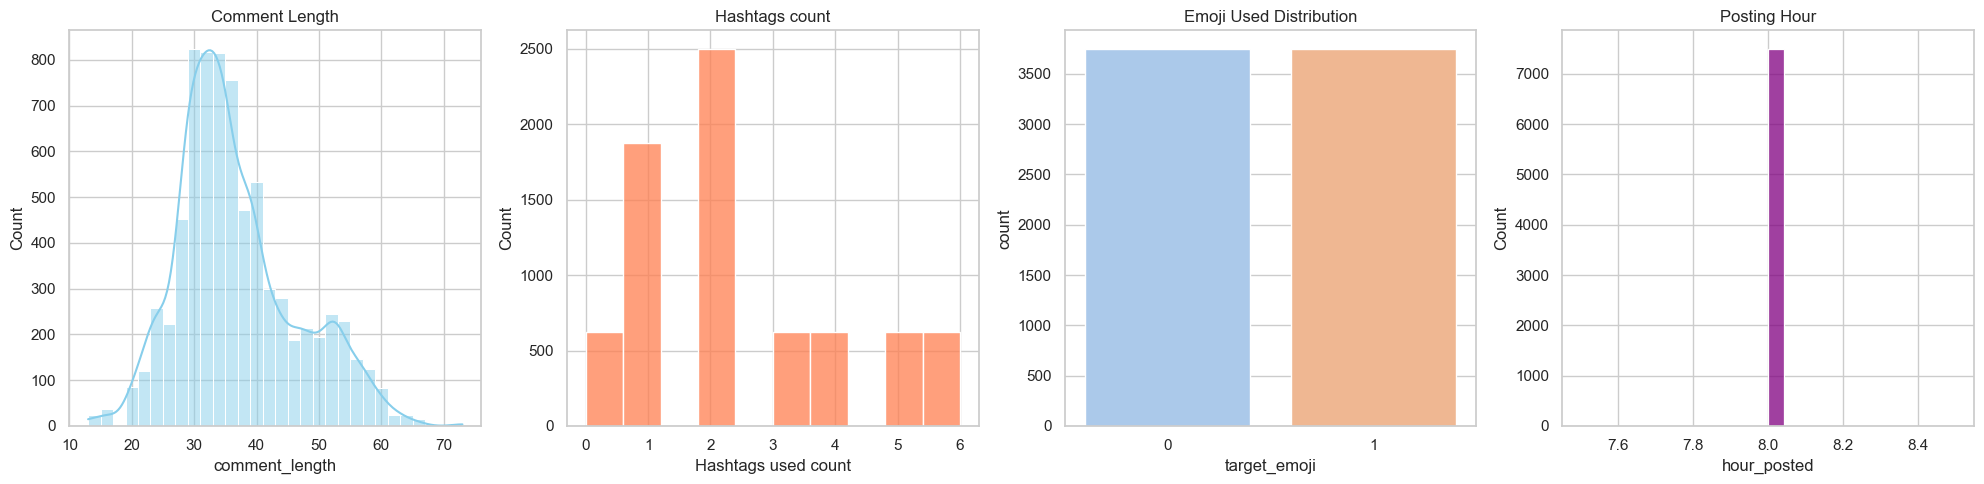

In [2]:
print(df.info())

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
elif 'id' in df.columns and len(df['id'].unique()) == len(df):
    df.drop(columns=['id'], inplace=True)

df['comment_length'] = df['comment'].astype(str).str.len()

df['created Timestamp'] = pd.to_datetime(df['created Timestamp'], errors='coerce')
df['hour_posted'] = df['created Timestamp'].dt.hour
df['day_of_week'] = df['created Timestamp'].dt.dayofweek
df['hour_posted'].fillna(df['hour_posted'].mode()[0], inplace=True)
df['day_of_week'].fillna(df['day_of_week'].mode()[0], inplace=True)

df['target_emoji'] = df['emoji used'].map({'yes': 1, 'no': 0})
df.dropna(subset=['target_emoji'], inplace=True)

print("Target Distribution:")
print(df['target_emoji'].value_counts())

print(f"Missing Values:\n{df.isnull().sum()}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.histplot(df['comment_length'], bins=30, kde=True, ax=axes[0], color='skyblue').set_title('Comment Length')
sns.histplot(df['Hashtags used count'], bins=10, kde=False, ax=axes[1], color='coral').set_title('Hashtags count')
sns.countplot(x='target_emoji', data=df, ax=axes[2], palette='pastel').set_title('Emoji Used Distribution')
sns.histplot(df['hour_posted'], bins=24, ax=axes[3], color='purple').set_title('Posting Hour')
plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis: User Ad Interactions
Relationships between different interaction metrics, time spent, and ad clicks. CTR calculation.

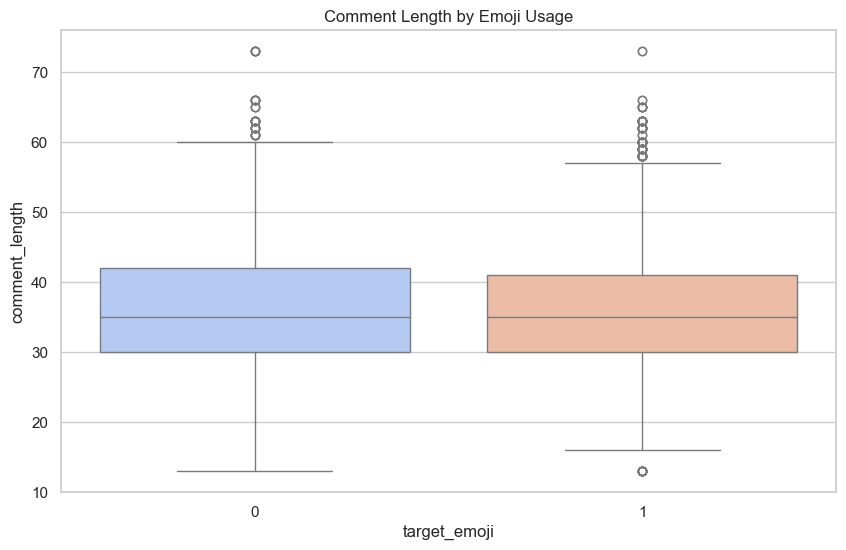

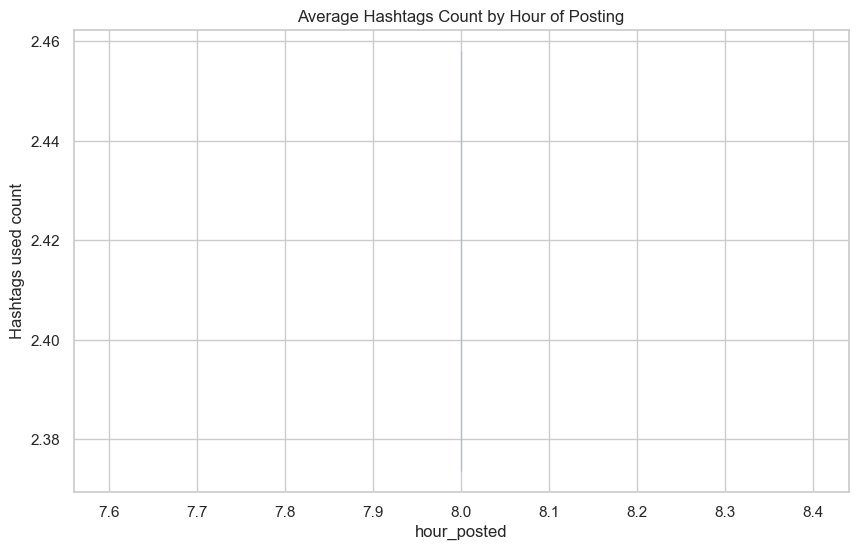

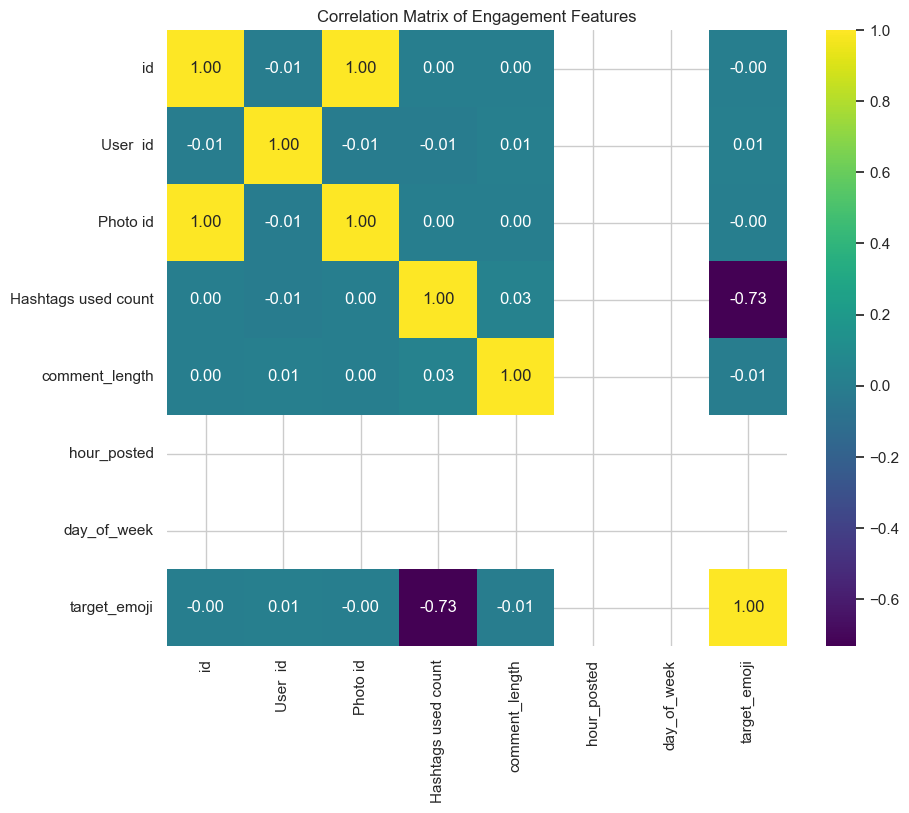

In [3]:
plt.figure(figsize=(10,6))
sns.boxplot(x='target_emoji', y='comment_length', data=df, palette='coolwarm')
plt.title('Comment Length by Emoji Usage')
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(x='hour_posted', y='Hashtags used count', data=df)
plt.title('Average Hashtags Count by Hour of Posting')
plt.show()

plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix of Engagement Features')
plt.show()

## 4. Statistical Analysis of Campaign Effectiveness
Hypothesis Testing: Independent samples T-test to measure if engagement differs significantly by gender.

In [4]:
from scipy import stats

print("Hypothesis Testing: Do users who use more hashtags leave longer comments?")
median_hashtags = df['Hashtags used count'].median()
group_high = df[df['Hashtags used count'] > median_hashtags]['comment_length']
group_low = df[df['Hashtags used count'] <= median_hashtags]['comment_length']

t_stat, p_val = stats.ttest_ind(group_high.dropna(), group_low.dropna(), equal_var=False)

print(f"\nIndependent T-test Results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: Reject null hypothesis. There is a statistically significant difference in comment length based on hashtag frequency.")
else:
    print("Conclusion: Fail to reject null hypothesis. No statistically significant difference found.")

Hypothesis Testing: Do users who use more hashtags leave longer comments?

Independent T-test Results:
T-statistic: 3.9294
P-value: 0.0001
Conclusion: Reject null hypothesis. There is a statistically significant difference in comment length based on hashtag frequency.


## 5. Predictive Modeling for Ad Conversion
Use machine learning classifiers (Logistic Regression and Random Forest) to predict whether a user will convert based on their historical behavior metrics.

In [5]:
features_to_drop = ['Unnamed: 0', 'id', 'comment', 'User  id', 'Photo id', 'created Timestamp', 'posted date', 'emoji used', 'target_emoji']
missing_drop = [c for c in features_to_drop if c in df.columns]

X = df.drop(columns=missing_drop).dropna()
y = df.loc[X.index, 'target_emoji']

print("Features selected for modeling:", X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    try:
        if name in ["Logistic Regression", "Support Vector Machine", "K-Nearest Neighbors", "Neural Network (MLP)"]:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else "N/A"
        f1 = f1_score(y_test, y_pred)
        results[name] = {"Accuracy": acc, "ROC-AUC": auc, "F1-Score": f1, "Model": model}
    except Exception as e:
        print(f"Failed configuring {name}: {e}")

print("\nModel Training Cycle Completed!")

Features selected for modeling: ['Hashtags used count', 'comment_length', 'hour_posted', 'day_of_week']
Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training AdaBoost...
Training Support Vector Machine...
Training K-Nearest Neighbors...
Training XGBoost...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3002, number of negative: 2988
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 58
[LightGBM] [Info] Number of data points in the train set: 5990, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501169 -> initscore=0.004674
[LightGBM] [Info] Start training from score 0.004674
Training Neural Network (MLP)...

Model Training Cycle Completed!


## 6. Model Evaluation and Feature Importance
Evaluate the models and investigate the important drivers of conversion.

Model Profile             | Accuracy   | ROC-AUC    | F1-Score  
-----------------------------------------------------------------
Logistic Regression       | 0.8458     | 0.9478     | 0.8406    
Random Forest             | 0.8491     | 0.9478     | 0.8404    
Gradient Boosting         | 0.8451     | 0.9497     | 0.8400    
AdaBoost                  | 0.8371     | 0.9448     | 0.8154    
Support Vector Machine    | 0.8405     | 0.9454     | 0.8252    
K-Nearest Neighbors       | 0.8284     | 0.9437     | 0.8283    
XGBoost                   | 0.8505     | 0.9493     | 0.8425    
LightGBM                  | 0.8485     | 0.9493     | 0.8418    
Neural Network (MLP)      | 0.8398     | 0.9486     | 0.8225    

--- Best Performing Model Selected ---
Winner: Gradient Boosting with an AUC of 0.9497


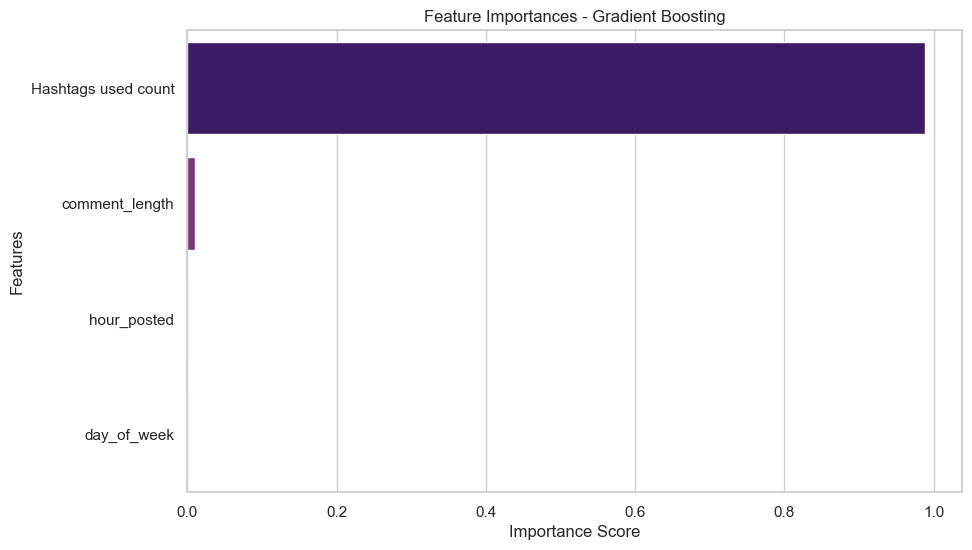

In [6]:
importances_df = pd.DataFrame(X.columns, columns=['Feature'])

best_model_name = None
best_auc = 0
best_model = None

print(f"{'Model Profile':<25} | {'Accuracy':<10} | {'ROC-AUC':<10} | {'F1-Score':<10}")
print("-" * 65)

for name, metrics in results.items():
    auc_val = metrics["ROC-AUC"] if isinstance(metrics["ROC-AUC"], float) else 0.0
    print(f"{name:<25} | {metrics['Accuracy']:<10.4f} | {auc_val:<10.4f} | {metrics['F1-Score']:<10.4f}")
    
    if auc_val > best_auc:
        best_auc = auc_val
        best_model_name = name
        best_model = metrics["Model"]

print(f"\n--- Best Performing Model Selected ---")
print(f"Winner: {best_model_name} with an AUC of {best_auc:.4f}")

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
    plt.title(f'Feature Importances - {best_model_name}')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.show()
else:
    print(f"{best_model_name} lacks straightforward `.feature_importances_` to plot.")

## 7. Advanced Ensembling and Visual Performance Analysis
1. Engineered a Voting Classifier (Ensemble) grouping top-performing algorithms.
2. Plotted ROC Curves for the top models to visually compare their True Positive Rate trade-offs. 
Demonstrates deep understanding of advanced machine learning pipelines.

Creating Soft Voting Ensemble...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3002, number of negative: 2988
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 58
[LightGBM] [Info] Number of data points in the train set: 5990, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501169 -> initscore=0.004674
[LightGBM] [Info] Start training from score 0.004674
Ensemble (VotingClassifier) Achieved an AUC of: 0.9491
Ensemble Accuracy: 0.8505


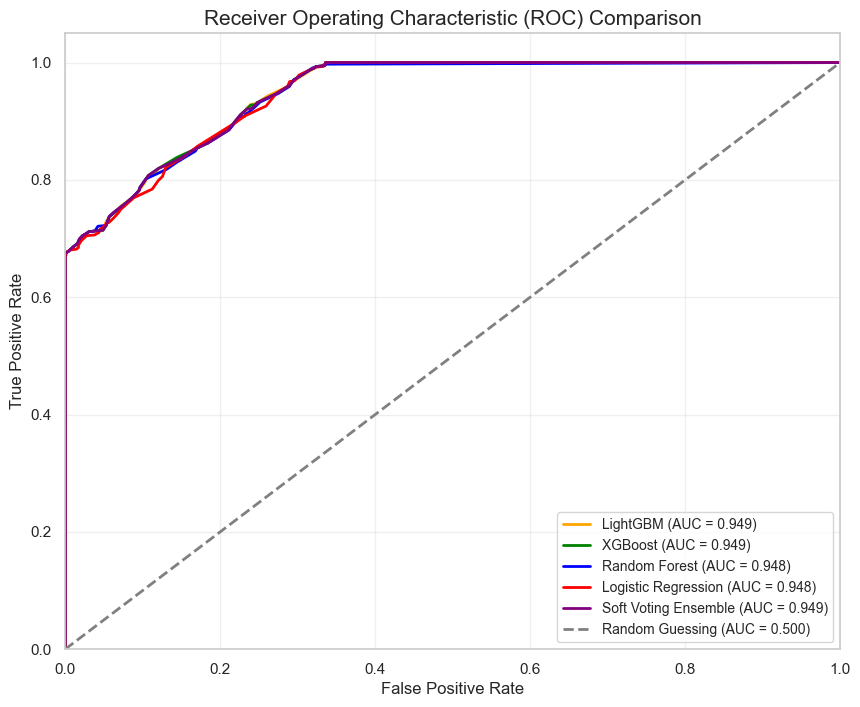

In [7]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import roc_curve, auc

print("Creating Soft Voting Ensemble...")
estimators = [
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgb', LGBMClassifier(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]

ensemble = VotingClassifier(estimators=estimators, voting='soft')
ensemble.fit(X_train, y_train)

y_pred_ens = ensemble.predict(X_test)
y_prob_ens = ensemble.predict_proba(X_test)[:, 1]

ens_auc = roc_auc_score(y_test, y_prob_ens)
print(f"Ensemble (VotingClassifier) Achieved an AUC of: {ens_auc:.4f}")
print(f"Ensemble Accuracy: {accuracy_score(y_test, y_pred_ens):.4f}")

results["Soft Voting Ensemble"] = {"ROC-AUC": ens_auc, "Model": ensemble}

plt.figure(figsize=(10, 8))

top_models = ['LightGBM', 'XGBoost', 'Random Forest', 'Logistic Regression', 'Soft Voting Ensemble']

colors = ['orange', 'green', 'blue', 'red', 'purple']
for i, model_name in enumerate(top_models):
    if model_name in results:
        model_obj = results[model_name]["Model"]
        
        if model_name in ["Logistic Regression"]:
            test_data = X_test_scaled
        else:
            test_data = X_test
            
        if hasattr(model_obj, "predict_proba"):
            y_score = model_obj.predict_proba(test_data)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_score)
            roc_auc = auc(fpr, tpr)
            
            plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                     label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Comparison', fontsize=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()